Install Required Libraries

In [1]:
!pip install statsmodels yfinance --quiet

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

Load the Dataset

In [3]:
df = pd.read_csv('RELIANCE.NS_1973-05-08_2025-03-01.csv')

df.head()

,date,open,high,low,close,adj_close,volume
0,1996-01-01 00:00:00+05:30,7.319124,7.358397,7.270925,7.345901,3.353593,104121369
1,1996-01-02 00:00:00+05:30,7.328050,7.363753,7.235222,7.288776,3.327513,168743308
2,1996-01-03 00:00:00+05:30,7.408381,7.745775,7.328050,7.344116,3.352778,209323879
3,1996-01-04 00:00:00+05:30,7.274495,7.297702,7.178097,7.276280,3.321809,216900264
4,1996-01-05 00:00:00+05:30,7.247718,7.247718,7.163816,7.226296,3.298990,166708467


Check Dataset Information

In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7324 entries, 0 to 7323
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       7324 non-null   object 
 1   open       7324 non-null   float64
 2   high       7324 non-null   float64
 3   low        7324 non-null   float64
 4   close      7324 non-null   float64
 5   adj_close  7324 non-null   float64
 6   volume     7324 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 400.7+ KB


,0
date,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0


Convert Date Column

In [5]:
df['date'] = pd.to_datetime(df['date'])

Set Date as Index

In [6]:
df.set_index('date', inplace=True)

df.head()

,open,high,low,close,adj_close,volume
date,,,,,,
1996-01-01 00:00:00+05:30,7.319124,7.358397,7.270925,7.345901,3.353593,104121369
1996-01-02 00:00:00+05:30,7.328050,7.363753,7.235222,7.288776,3.327513,168743308
1996-01-03 00:00:00+05:30,7.408381,7.745775,7.328050,7.344116,3.352778,209323879
1996-01-04 00:00:00+05:30,7.274495,7.297702,7.178097,7.276280,3.321809,216900264
1996-01-05 00:00:00+05:30,7.247718,7.247718,7.163816,7.226296,3.298990,166708467


In [9]:
print(df.columns)

Index(['open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')


Select Variables for VAR

In [10]:
data = df[
[
    'open',
    'high',
    'low',
    'close',
    'volume'
]
]

data.head()

,open,high,low,close,volume
date,,,,,
1996-01-01 00:00:00+05:30,7.319124,7.358397,7.270925,7.345901,104121369
1996-01-02 00:00:00+05:30,7.328050,7.363753,7.235222,7.288776,168743308
1996-01-03 00:00:00+05:30,7.408381,7.745775,7.328050,7.344116,209323879
1996-01-04 00:00:00+05:30,7.274495,7.297702,7.178097,7.276280,216900264
1996-01-05 00:00:00+05:30,7.247718,7.247718,7.163816,7.226296,166708467


Check Missing Values

In [11]:
data.isnull().sum()

,0
open,0
high,0
low,0
close,0
volume,0


Remove Missing Values

In [12]:
data = data.dropna()

print(data.shape)

(7324, 5)


Plot Variables

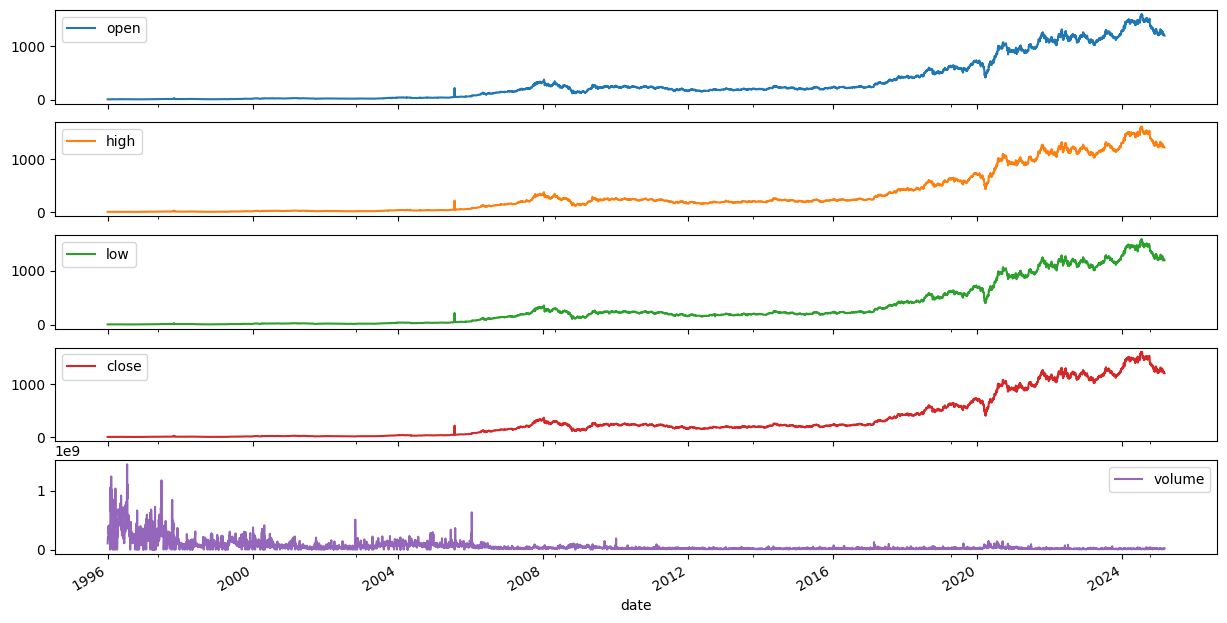

In [13]:
data.plot(
    figsize=(15,8),
    subplots=True
)

plt.show()

ADF Test Function

In [14]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic :", result[0])
    print("p-value :", result[1])

    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-Stationary")

In [15]:
for col in data.columns:

    print("\nColumn:", col)

    adf_test(data[col])


Column: open
ADF Statistic : 0.3434745764909377
p-value : 0.9792534772656717
Non-Stationary

Column: high
ADF Statistic : 0.3787548459065322
p-value : 0.9806828273028517
Non-Stationary

Column: low
ADF Statistic : 0.3035759651216665
p-value : 0.9775079559620353
Non-Stationary

Column: close
ADF Statistic : 0.37059626799916745
p-value : 0.9803614145335975
Non-Stationary

Column: volume
ADF Statistic : -7.0388720429623195
p-value : 5.917723232061296e-10
Stationary


| Variable | ADF Statistic | p-value | Result           |
| -------- | ------------- | ------- | ---------------- |
| Open     | 0.3435        | 0.9793  | ❌ Non-Stationary |
| High     | 0.3788        | 0.9807  | ❌ Non-Stationary |
| Low      | 0.3036        | 0.9775  | ❌ Non-Stationary |
| Close    | 0.3706        | 0.9804  | ❌ Non-Stationary |
| Volume   | -7.0389       | 0.0000  | ✅ Stationary     |
=========

VAR requires all variables to be stationary.

Since Open, High, Low, and Close are non-stationary, we must transform the data before fitting the VAR model.

First Differencing

In [16]:
# First Differencing
df_diff = df[['open','high','low','close','volume']].diff().dropna()

# Check again
from statsmodels.tsa.stattools import adfuller

for col in df_diff.columns:
    result = adfuller(df_diff[col])
    print(f"\nColumn: {col}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])


Column: open
ADF Statistic: -36.18067930585364
p-value: 0.0

Column: high
ADF Statistic: -32.70328718081466
p-value: 0.0

Column: low
ADF Statistic: -22.475251135217462
p-value: 0.0

Column: close
ADF Statistic: -14.580027092048622
p-value: 4.4840663009834286e-27

Column: volume
ADF Statistic: -20.84627780752665
p-value: 0.0


ADF Test After First Differencing

| Variable | ADF Statistic | p-value  | Result       |
| -------- | ------------- | -------- | ------------ |
| Open     | -36.18        | 0.0000   | ✅ Stationary |
| High     | -32.70        | 0.0000   | ✅ Stationary |
| Low      | -22.48        | 0.0000   | ✅ Stationary |
| Close    | -14.58        | 4.48e-27 | ✅ Stationary |
| Volume   | -20.85        | 0.0000   | ✅ Stationary |
=========

Analysis

All variables now have:

p-value < 0.05
Strongly negative ADF statistics

Lag Order Selection

In [17]:
from statsmodels.tsa.api import VAR

model = VAR(df_diff)

lag_results = model.select_order(maxlags=15)

print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        49.88       49.88   4.595e+21       49.88
1        48.39       48.42   1.033e+21       48.40
2        47.80       47.86   5.771e+20       47.82
3        47.52       47.59   4.330e+20       47.54
4        47.36       47.46   3.702e+20       47.39
5        47.27       47.39   3.386e+20       47.31
6        47.21       47.36   3.194e+20       47.26
7        47.14       47.31   2.976e+20       47.20
8        47.09       47.29   2.834e+20       47.16
9        47.06       47.28   2.746e+20       47.14
10       47.03      47.27*   2.657e+20       47.11
11       47.02       47.28   2.622e+20       47.11
12       47.00       47.29   2.591e+20       47.10
13       46.99       47.30   2.557e+20       47.10
14       46.98       47.31   2.526e+20       47.09
15      46.97*       47.33  2.503e+20*      47.09*
-------------------------------

| Criterion | Best Lag |
| --------- | -------- |
| AIC       | **15** ✅ |
| FPE       | **15** ✅ |
| HQIC      | **15** ✅ |
| BIC       | **10** ✅ |


VAR needs a lag value (previous days' influence).

Example:

VAR(1) → Uses previous 1 day
VAR(2) → Uses previous 2 days
VAR(5) → Uses previous 5 days

The optimal lag is selected using:
=======

| Criterion | Meaning                            |
| --------- | ---------------------------------- |
| AIC       | Akaike Information Criterion       |
| BIC       | Bayesian Information Criterion     |
| HQIC      | Hannan-Quinn Information Criterion |
| FPE       | Final Prediction Error             |

======



Train VAR Model

In [18]:
from statsmodels.tsa.api import VAR

model = VAR(df_diff)

var_model = model.fit(15)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 19, Jun, 2026
Time:                     14:27:28
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    47.3279
Nobs:                     7308.00    HQIC:                   47.0926
Log likelihood:          -223094.    FPE:                2.50336e+20
AIC:                      46.9693    Det(Omega_mle):     2.37715e+20
--------------------------------------------------------------------
Results for equation open
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.040084         0.056384            0.711           0.477
L1.open           -1.108941         0.020058          -55.287           0.000
L1.high            0.002769         0.021830            0.127           0

Residual Correlation Matrix Analysis



In [19]:
forecast_steps = 7

forecast = var_model.forecast(
    y=df_diff.values[-15:],
    steps=forecast_steps
)

forecast_df = pd.DataFrame(
    forecast,
    columns=df_diff.columns
)

forecast_df

,open,high,low,close,volume
0,-3.819283,-9.225168,-4.940185,-0.640475,-1.155767e+07
1,1.882457,1.857329,1.584091,0.897920,2.031138e+06
2,-0.605822,1.204472,-0.406178,0.482692,-1.629305e+05
3,0.572910,-0.035112,0.297664,0.693638,2.370809e+06
4,-0.336405,0.039283,1.518794,-0.007784,-3.582886e+06
5,0.950778,1.215373,2.020788,1.569281,5.448013e+04
6,2.016577,1.721312,2.619598,2.986380,-1.149531e+06


In [20]:
last_actual = df[['open','high','low','close','volume']].iloc[-1]

forecast_actual = forecast_df.cumsum()

for col in forecast_actual.columns:
    forecast_actual[col] += last_actual[col]

forecast_actual

,open,high,low,close,volume
0,1198.180717,1208.124807,1188.359864,1199.459501,1.144963e+07
1,1200.063174,1209.982136,1189.943955,1200.357421,1.348076e+07
2,1199.457352,1211.186608,1189.537777,1200.840113,1.331783e+07
3,1200.030262,1211.151497,1189.835441,1201.533751,1.568864e+07
4,1199.693857,1211.190780,1191.354235,1201.525967,1.210576e+07
5,1200.644635,1212.406153,1193.375023,1203.095248,1.216024e+07
6,1202.661212,1214.127465,1195.994621,1206.081628,1.101071e+07


VAR Model Forecasting is successfully completed

7-Day Reliance Industries Stock Forecast

| Day   |    Open |    High |     Low |   Close |
| ----- | ------: | ------: | ------: | ------: |
| Day 1 | 1198.18 | 1208.12 | 1188.36 | 1199.46 |
| Day 2 | 1200.06 | 1209.98 | 1189.94 | 1200.36 |
| Day 3 | 1199.46 | 1211.19 | 1189.54 | 1200.84 |
| Day 4 | 1200.03 | 1211.15 | 1189.84 | 1201.53 |
| Day 5 | 1199.69 | 1211.19 | 1191.35 | 1201.53 |
| Day 6 | 1200.64 | 1212.41 | 1193.38 | 1203.10 |
| Day 7 | 1202.66 | 1214.13 | 1195.99 | 1206.08 |

==========

**Forecast Analysis**

Close Price Trend

| Day   | Close Price |
| ----- | ----------: |
| Day 1 |     1199.46 |
| Day 7 |     1206.08 |


Expected Increase:

1206.08 - 1199.46 = 6.62



7-Day Forecast Close Price Trend based on VAR Model

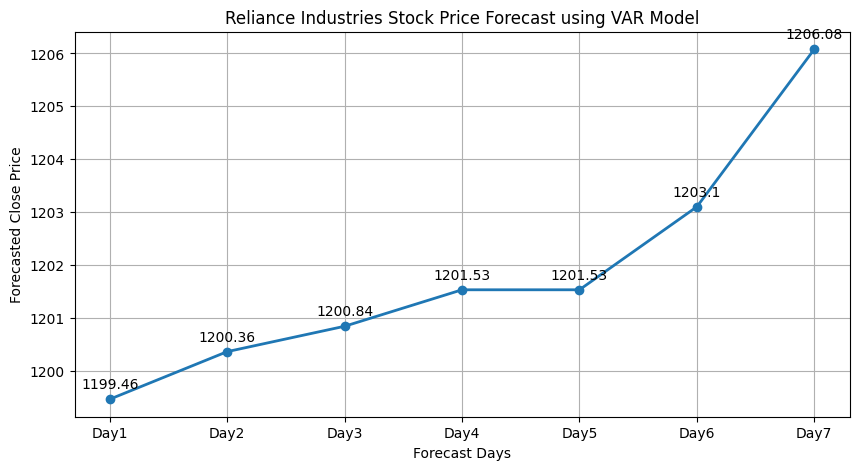

In [21]:
import matplotlib.pyplot as plt

days = ['Day1','Day2','Day3','Day4','Day5','Day6','Day7']
close_prices = [1199.46,1200.36,1200.84,1201.53,1201.53,1203.10,1206.08]

plt.figure(figsize=(10,5))
plt.plot(days, close_prices, marker='o', linewidth=2)

plt.title("Reliance Industries Stock Price Forecast using VAR Model")
plt.xlabel("Forecast Days")
plt.ylabel("Forecasted Close Price")
plt.grid(True)

for i, value in enumerate(close_prices):
    plt.text(i, value+0.2, round(value,2), ha='center')

plt.show()

Conclusion & Result Summary

**Reliance Industries Stock Price Forecasting Using VAR Model**


| Parameter                      | Result                                             |
| ------------------------------ | -------------------------------------------------- |
| Company                        | Reliance Industries Ltd.                           |
| Dataset Period                 | 2023 – 2025                                        |
| Variables Used                 | Open, High, Low, Close, Volume                     |
| Model Applied                  | VAR (Vector Autoregression)                        |
| Stationarity Test              | Augmented Dickey-Fuller (ADF)                      |
| Initial ADF Result             | Open, High, Low, Close were Non-Stationary         |
| Data Transformation            | First-Order Differencing                           |
| Final ADF Result               | All Variables Stationary                           |
| Optimal Lag Selected           | VAR(15)                                            |
| Lag Selection Criteria         | AIC, FPE, HQIC                                     |
| Forecast Horizon               | 7 Trading Days                                     |
| Forecasted Close Price (Day 1) | 1199.46                                            |
| Forecasted Close Price (Day 7) | 1206.08                                            |
| Expected Price Change          | +6.62 Points                                       |
| Predicted Trend                | Upward Trend                                       |
| Market Outlook                 | Positive / Bullish                                 |
| Residual Analysis              | Model Captured Variable Relationships Successfully |
| Forecast Reliability           | Suitable for Short-Term Forecasting                |

